<a href="https://colab.research.google.com/github/divyansshu/pytorch/blob/main/pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Libraries in pytorch
1. `torchvision`: base domain library for ptytorch computer vision
2. `torchvision.datasets`: get datasets and dataloading functions for computer vision here
3. `torchvision.models`: get pretrained computer vision models that you can leverage for your own problems
4. `torchvision.transforms`: functions for manipulating your vision data (images) to be suitable for use with an ML model
5. `torch.utils.data.Dataset`: Base dataset class for pytorch
6. `torch.utils.data.DataLoader`: creates a python iterable for dataset

In [ ]:
import torch
from torch import nn
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_idx = train_data.class_to_idx
class_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

Text(0.5, 1.0, '9')

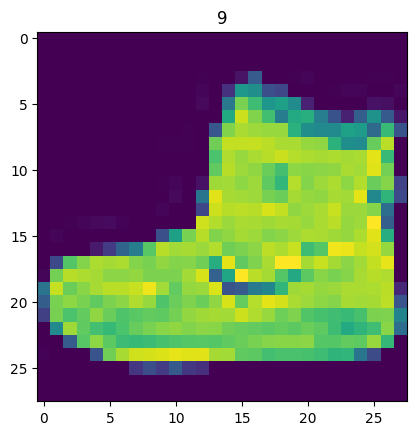

In [ ]:
image, label = train_data[0]
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

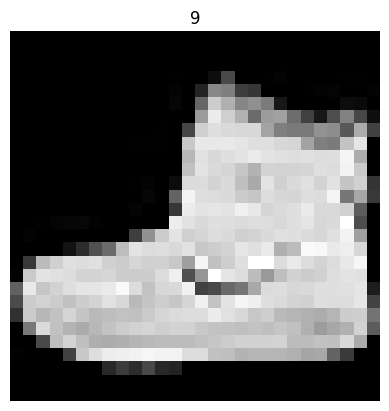

In [ ]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(label)
plt.axis(False)

right now our data is in pytorch datasets
DataLoader turns our dataset into python iterable
more specifically, we want to turn our data into batches.


In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE=32

# turn datasets into iterable (batches)
train_dataLoader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataLoader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False)

In [ ]:
print(f'length of train_dataloader: {len(train_dataLoader)} batches of {BATCH_SIZE}')
print(f'length of test_dataloader: {len(test_dataLoader)} batches of {BATCH_SIZE}')

length of train_dataloader: 1875 batches of 32
length of test_dataloader: 313 batches of 32


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataLoader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 7, label size: torch.Size([])


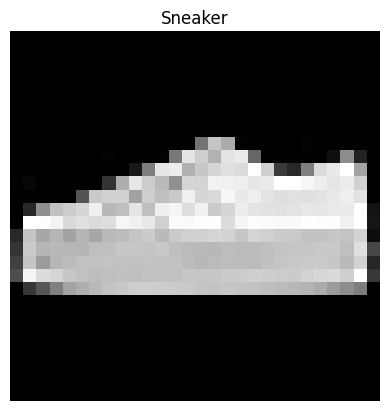

In [ ]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f'Image size: {img.shape}')
print(f'Label: {label}, label size: {label.shape}')

In [ ]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)

print(f'Shape before flattening: {x.shape}')
print(f'Shape after flattening: {output.shape}')

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [ ]:
#  1. Baseline model- linear
# class FashionMNISTModel(nn.Module):
#   def __init__(self, input_shape, hidden_units, output_shape):
#     super().__init__()

#     self.layers_stack = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(in_features=input_shape, out_features=hidden_units),
#         nn.Linear(in_features=hidden_units, out_features=output_shape)
#     )

#   def forward(self, x):
#     return self.layers_stack(x)

# 2. Introducing non linearity in baseline model
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layers_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_shape, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, output_shape),
        nn.ReLU()
    )

  def forward(self, x):
    return self.layers_stack(x)


In [ ]:
model_0 = FashionMNISTModel(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_0

FashionMNISTModel(
  (layers_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [ ]:
# calculate accuracy
def accuracy(y_true, y_pred):
  correct = torch.eq(y_pred, y_true).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.01)

In [ ]:
from tqdm.auto import tqdm # progress bar
epochs = 5

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n------------')
  train_loss = 0
  for batch, (X, y) in enumerate(train_dataLoader):
    X, y = X.to(device), y.to(device)
    model_0.train()

    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc = accuracy(y, y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataLoader)

  test_loss, test_acc = 0,0
  model_0.to(device)
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataLoader:
      X, y = X.to(device), y.to(device)
      test_preds = model_0(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy(y, test_preds.argmax(dim=1))
    test_loss /= len(test_dataLoader)
    test_acc /= len(test_dataLoader)

  print(f'Train loss: {train_loss:.5f} Train accuracy: {train_acc:.2f}% Test loss: {test_loss:.5f} Test accuracy: {test_acc:.2f}%')


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
------------
Train loss: 1.24776 Train accuracy: 56.25% Test loss: 1.17124 Test accuracy: 64.66%
Epoch: 1
------------
Train loss: 1.09696 Train accuracy: 56.25% Test loss: 1.10286 Test accuracy: 67.31%
Epoch: 2
------------
Train loss: 1.07698 Train accuracy: 78.12% Test loss: 1.17789 Test accuracy: 64.96%
Epoch: 3
------------
Train loss: 1.06898 Train accuracy: 68.75% Test loss: 1.12965 Test accuracy: 64.98%
Epoch: 4
------------
Train loss: 1.05780 Train accuracy: 62.50% Test loss: 1.10461 Test accuracy: 66.10%


In [ ]:
# create a convolutional neural network
class FashionMNISTModel_v2(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
        kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
        kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units* 0,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    print(x.shape)
    x = self.conv_block_2(x)
    print(x.shape)
    x = self.classifier(x)
    return x